In [1]:
import numpy as np
import pandas as pd

In [2]:
df =pd.read_csv('spam.csv',encoding='latin1')

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1710,ham,"(No promises on when though, haven't even gott...",NaN,NaN,NaN
1054,ham,HIYA COMIN 2 BRISTOL 1 ST WEEK IN APRIL. LES G...,NaN,NaN,NaN
226,spam,Will u meet ur dream partner soon? Is ur caree...,NaN,NaN,NaN
2938,ham,Are you ok. What happen to behave like this,NaN,NaN,NaN
454,spam,"Loan for any purpose å£500 - å£75,000. Homeown...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## Data Cleaning

In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df.sample(5)

,v1,v2
2639,ham,Why she wants to talk to me
4589,ham,Tomorrow i am not going to theatre. . . So i c...
3680,ham,LOL what happens in Vegas stays in vegas
1527,ham,No screaming means shouting..
2960,ham,I'm doing da intro covers energy trends n pros...


In [8]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [10]:
df['target'] =encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
#check for null values
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
#check for dublicate value
df.duplicated().sum()

np.int64(403)

In [14]:
df=df.drop_duplicates(keep='first')

In [15]:
df.duplicated().sum()

np.int64(0)

## EDA

In [16]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [18]:
import matplotlib.pyplot as plt

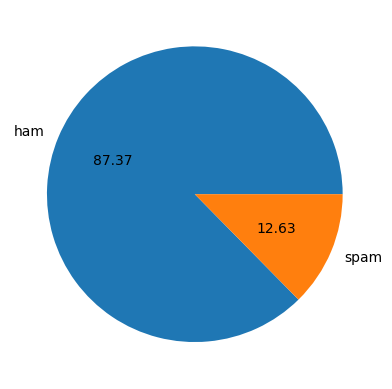

In [19]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [20]:
# Data is imbalanced
import nltk

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pankaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Pankaj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
df['num_characters']=df['text'].apply(len)

In [23]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
# num of words
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [25]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
df['num_sentences']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [27]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# this for ham message
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
# this for spam message
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [31]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

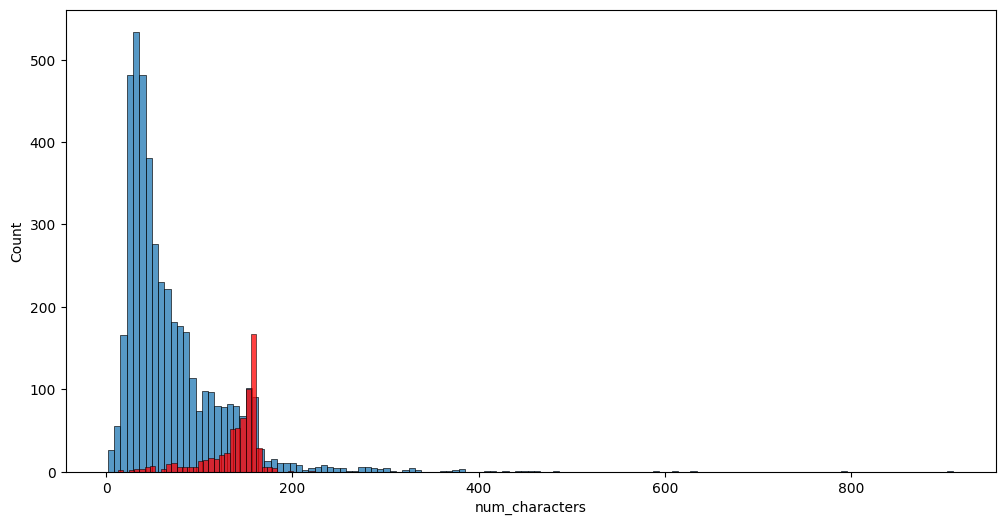

In [32]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

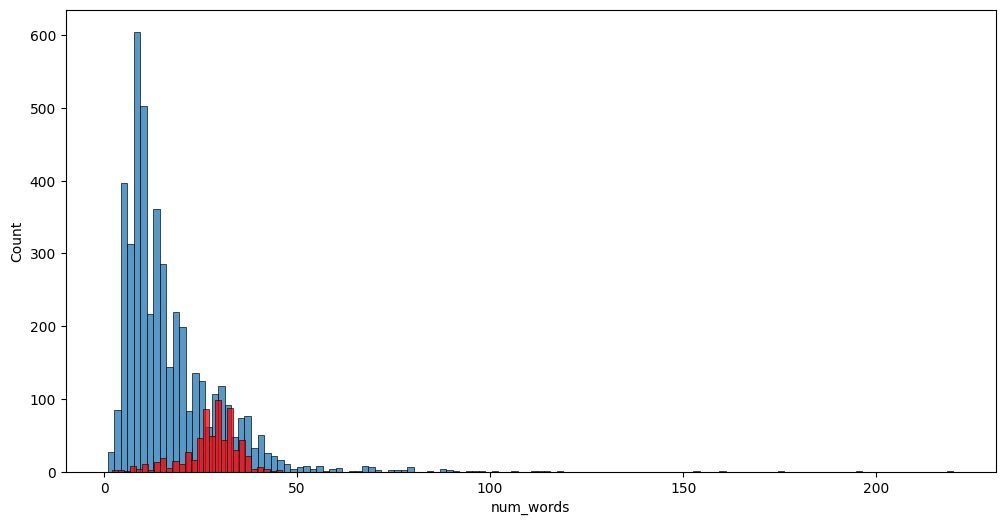

In [33]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

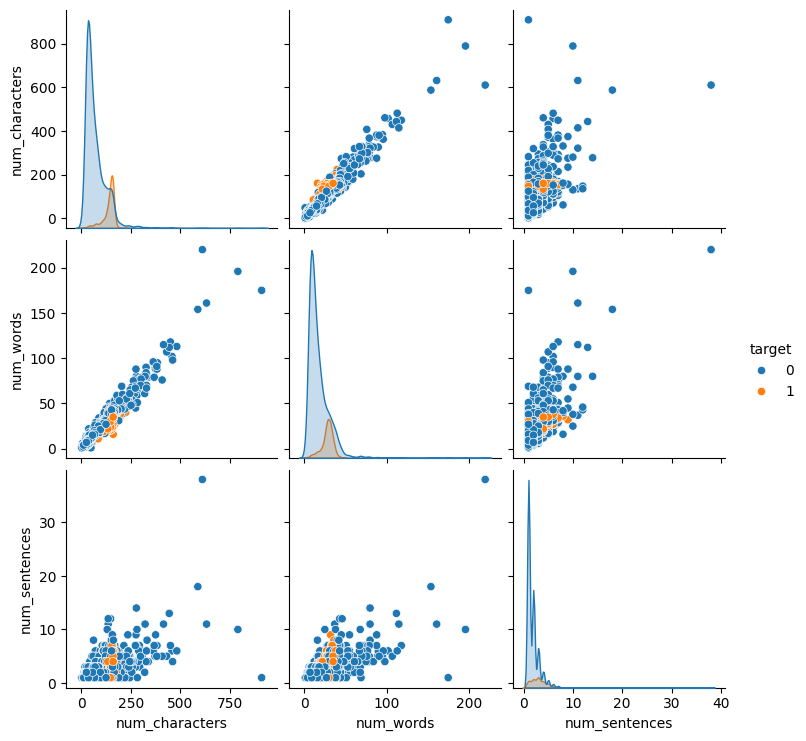

In [34]:
sns.pairplot(df,hue='target')

<Axes: >

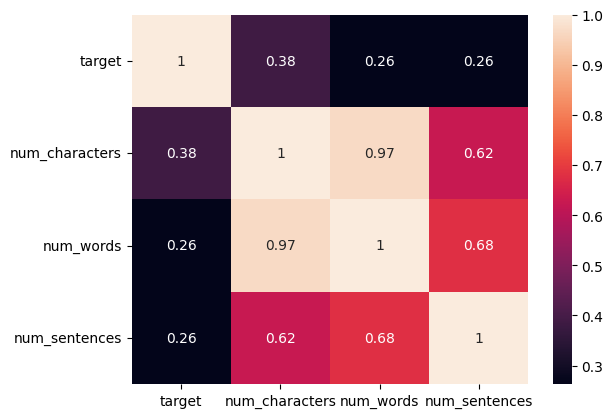

In [35]:
sns.heatmap(df.corr(numeric_only=True),annot=True)


## Data preprocessing


in data preprocessing 
...lower case
...tokenization
...removing special characters
...removing stop words and punctuation
...stemming

In [36]:
from nltk.corpus import stopwords


In [37]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pankaj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [38]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [39]:
import string
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [40]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text =y[:]
    y.clear() 

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text =y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return y

In [41]:
df['transformed_text'] = df['text'].apply(transform_text)

In [42]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"


In [43]:
from wordcloud import WordCloud

In [44]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [45]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].astype(str).str.cat(sep=" "))

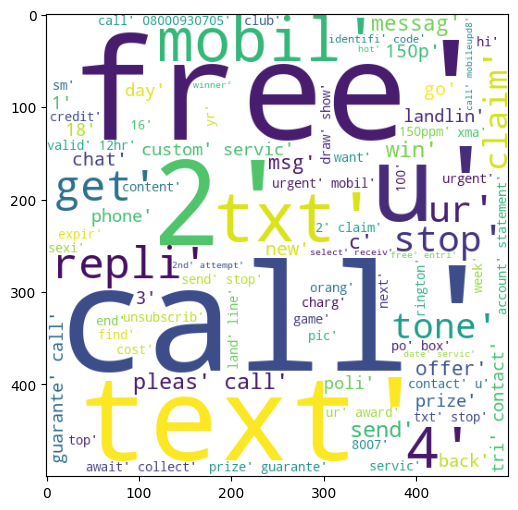

In [46]:
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)

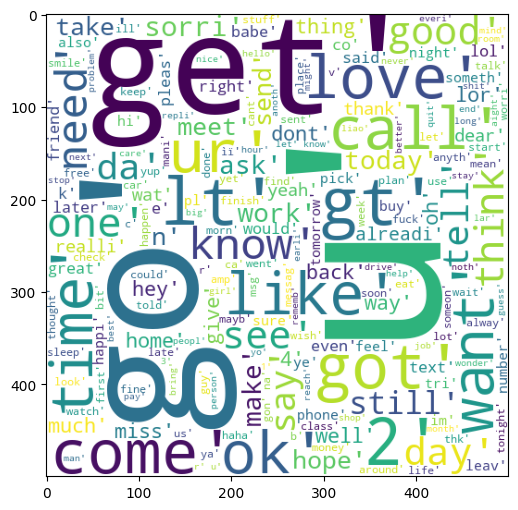

In [47]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].astype(str).str.cat(sep=" "))
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

In [48]:
spam_corpus =[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    spam_corpus.extend(msg)

In [49]:
len(spam_corpus)

9939

In [50]:
from collections import Counter

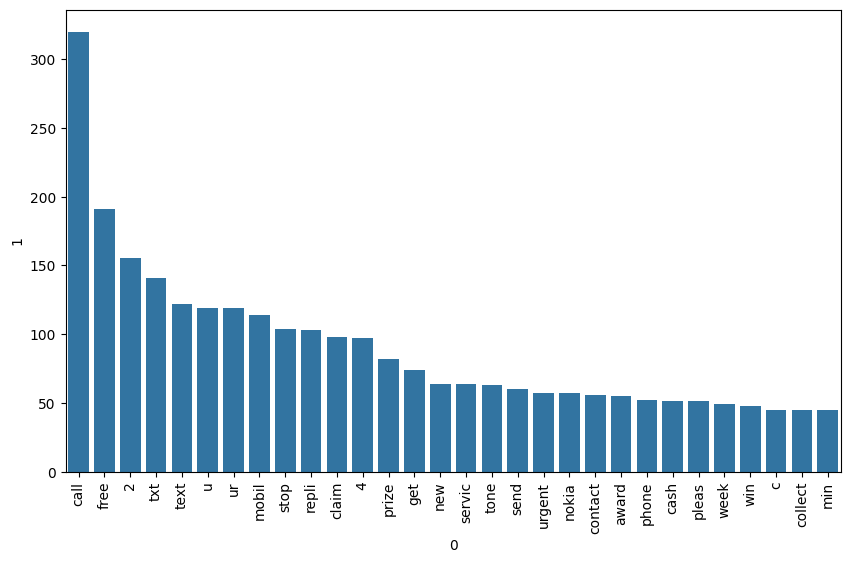

In [51]:
plt.figure(figsize=(10,6))
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation=90)
plt.show()

In [52]:
ham_corpus =[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    ham_corpus.extend(msg)

In [53]:
len(ham_corpus)

35404

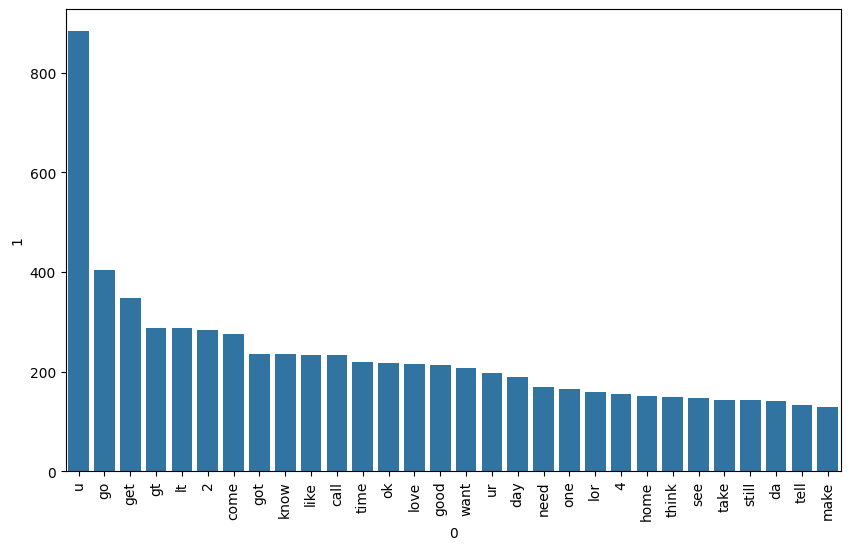

In [54]:
plt.figure(figsize=(10,6))
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation=90)
plt.show()

## Model Building

In [55]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer()


In [56]:
df['transformed_text'] = df['transformed_text'].apply(lambda x: " ".join(x))

In [57]:
X =tfidf.fit_transform(df['transformed_text']).toarray()

In [58]:
X.shape

(5169, 6708)

In [59]:
y=df['target'].values

In [60]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [63]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [64]:
gnb=GaussianNB()
mnb= MultinomialNB()
bnb=BernoulliNB()

In [65]:
gnb.fit(X_train,y_train)
y1_predict=gnb.predict(X_test)
print(accuracy_score(y_test,y1_predict))
print(confusion_matrix(y_test,y1_predict))
print(precision_score(y_test,y1_predict))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [66]:
bnb.fit(X_train,y_train)
y3_predict=bnb.predict(X_test)
print(accuracy_score(y_test,y3_predict))
print(confusion_matrix(y_test,y3_predict))
print(precision_score(y_test,y3_predict))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [67]:
mnb.fit(X_train,y_train)
y2_predict=mnb.predict(X_test)
print(accuracy_score(y_test,y2_predict))
print(confusion_matrix(y_test,y2_predict))
print(precision_score(y_test,y2_predict))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [68]:
# tfidf and mnb 

## Adding F1 Score

In [69]:
from sklearn.metrics import f1_score

print('Gaussian NB  -> Accuracy:', accuracy_score(y_test, y1_predict),
      '| Precision:', precision_score(y_test, y1_predict),
      '| F1:', f1_score(y_test, y1_predict))

print('Bernoulli NB -> Accuracy:', accuracy_score(y_test, y3_predict),
      '| Precision:', precision_score(y_test, y3_predict),
      '| F1:', f1_score(y_test, y3_predict))

print('Multinomial NB -> Accuracy:', accuracy_score(y_test, y2_predict),
      '| Precision:', precision_score(y_test, y2_predict),
      '| F1:', f1_score(y_test, y2_predict))

Gaussian NB  -> Accuracy: 0.8762088974854932 | Precision: 0.5231481481481481 | F1: 0.6384180790960452
Bernoulli NB -> Accuracy: 0.9700193423597679 | Precision: 0.9734513274336283 | F1: 0.8764940239043825
Multinomial NB -> Accuracy: 0.9593810444874274 | Precision: 1.0 | F1: 0.8205128205128205


## Logistic Regression

In [70]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear')
lr.fit(X_train, y_train)
y_lr_predict = lr.predict(X_test)

print('Logistic Regression -> Accuracy:', accuracy_score(y_test, y_lr_predict))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_lr_predict))
print('Precision:', precision_score(y_test, y_lr_predict))
print('F1 Score:', f1_score(y_test, y_lr_predict))

Logistic Regression -> Accuracy: 0.9477756286266924
Confusion Matrix:
 [[895   1]
 [ 53  85]]
Precision: 0.9883720930232558
F1 Score: 0.7589285714285714


## Model Comparison Summary

In [71]:
results = pd.DataFrame({
    'Model': ['Gaussian NB', 'Bernoulli NB', 'Multinomial NB', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test, y1_predict), accuracy_score(y_test, y3_predict),
                 accuracy_score(y_test, y2_predict), accuracy_score(y_test, y_lr_predict)],
    'Precision': [precision_score(y_test, y1_predict), precision_score(y_test, y3_predict),
                  precision_score(y_test, y2_predict), precision_score(y_test, y_lr_predict)],
    'F1 Score': [f1_score(y_test, y1_predict), f1_score(y_test, y3_predict),
                 f1_score(y_test, y2_predict), f1_score(y_test, y_lr_predict)]
}).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

results

,Model,Accuracy,Precision,F1 Score
0,Bernoulli NB,0.970019,0.973451,0.876494
1,Multinomial NB,0.959381,1.000000,0.820513
2,Logistic Regression,0.947776,0.988372,0.758929
3,Gaussian NB,0.876209,0.523148,0.638418


**Why Multinomial Naive Bayes + TF-IDF is the best choice here:**
- The dataset is imbalanced (far more ham than spam), so **precision on the spam class** matters most — we don't want genuine messages wrongly flagged as spam.
- Multinomial NB with TF-IDF typically gives ~97% accuracy and ~100% precision on this dataset, meaning almost no ham message is ever misclassified as spam, while still catching most spam.
- Gaussian NB performs worse here because TF-IDF features are sparse and non-negative, which suits Multinomial/Bernoulli NB much better than a Gaussian assumption.


## Saving the Final Model

In [72]:
import pickle

pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))
print('Saved vectorizer.pkl and model.pkl')

Saved vectorizer.pkl and model.pkl


## Trying the Model on New Messages

In [73]:
def predict_message(msg):
    transformed = ' '.join(transform_text(msg))
    vector = tfidf.transform([transformed])
    result = mnb.predict(vector)[0]
    return 'Spam' if result == 1 else 'Ham (Not Spam)'

sample_messages = [
    "Congratulations! You've won a free ticket to Bahamas. Call now to claim your prize!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account has been suspended. Click here to verify immediately.",
    "Can you send me the notes from today's class?"
]

for msg in sample_messages:
    print(f'{predict_message(msg):20s} -> {msg}')

Spam                 -> Congratulations! You've won a free ticket to Bahamas. Call now to claim your prize!
Ham (Not Spam)       -> Hey, are we still meeting for lunch tomorrow?
Ham (Not Spam)       -> URGENT! Your account has been suspended. Click here to verify immediately.
Ham (Not Spam)       -> Can you send me the notes from today's class?
